In [13]:
# Arquitectura de la red neuronal
 # Input
 # Flatten
 # Dense (128 neuronas, función de activación ReLU)
 # Dropout (regularización)
 # Dense (10 neuronas, salida)


#Usar ADA de optimizador
#Learning rate de 0.01
#Usar de 15 a 20 epocas
#Sparse categorical crossentropy(from_logits=True)
#Usar accuracy como metrica

In [14]:
#importar librerias numPy, pandas, matplotlib, tensorflow, sklearn, keras, mas importantes para utilizar una red neuronal.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers 


In [15]:
#imprime la version de python, tensorflow, keras, numpy, pandas.
print("Python version:", tf.__version__)
print("TensorFlow version:", tf.__version__)        
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python version: 2.19.0
TensorFlow version: 2.19.0
Keras version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [16]:
# Cargar el dataset MNIST
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [17]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


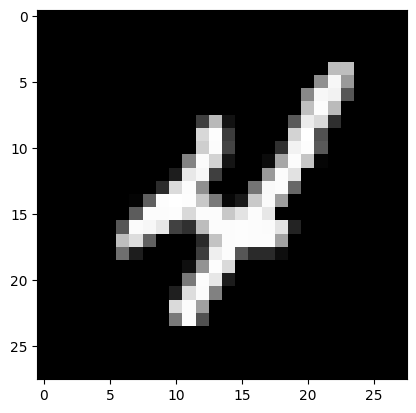

In [18]:
# Imprima la imagen del arreglo xtrain[0] 
plt.imshow(x_train[9], cmap='gray')
plt.show()

In [19]:
print(f"Label of the first training image: {y_train[9]}")

Label of the first training image: 4


In [20]:
print(f"Minimum value in x_train: {x_train.min()}")
print(f"Maximum value in x_train: {x_train.max()}")

Minimum value in x_train: 0
Maximum value in x_train: 255


In [21]:
# Normalizar los datos
x_train, x_test = x_train / 255.0, x_test / 255.0
# Imprimir el valor mínimo y máximo de x_train después de la normalización
print(f"Minimum value in x_train after normalization: {x_train.min()}")
print(f"Maximum value in x_train after normalization: {x_train.max()}")

Minimum value in x_train after normalization: 0.0
Maximum value in x_train after normalization: 1.0


In [22]:
!nvidia-smi

Fri Feb 27 19:51:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
# Inicializar la función perdida de entropía cruzada categórica esparsa
sparse_categorical_crossentropy = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Optimizador ADAM con learning rate de 0.01
adam_optimizer = keras.optimizers.Adam(learning_rate=0.01)

In [25]:
# Cree una variable llamada métrica, donde la métrica sea la precisión (accuracy)
accuracy_metric = keras.metrics.SparseCategoricalAccuracy()

In [26]:
# Definir el modelo secuencial
# La capa de salida va a tener 10 unidades con función de activación lineal
Mi_Modelo = keras.Sequential([
    # Capa de entrada con la forma de la imagen (28x28)
    keras.Input(shape=(28, 28)),
    # Capa para aplanar la entrada
    layers.Flatten(),
    # Capa densa de 128 neuronas con activación ReLU
    layers.Dense(128, activation='relu'),
    # Capa de Dropout para regularización
    layers.Dropout(0.2),
    # Capa de salida con 10 neuronas (una por dígito) (lineal por defecto)
    layers.Dense(10)
])

# Resumen del modelo
Mi_Modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Entrenar el modelo
Mi_Modelo.compile(optimizer=adam_optimizer,
              loss=sparse_categorical_crossentropy,
              metrics=[accuracy_metric])
Mi_Modelo.fit(x_train, y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4094 - sparse_categorical_accuracy: 0.8746
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2409 - sparse_categorical_accuracy: 0.9329
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2169 - sparse_categorical_accuracy: 0.9408
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2053 - sparse_categorical_accuracy: 0.9436
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1979 - sparse_categorical_accuracy: 0.9467
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1887 - sparse_categorical_accuracy: 0.9494
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1996 - sparse_categorical_accuracy: 0.9477
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1795 - sparse_categorical_accuracy: 0.9525
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1841 - sparse_categorical_accuracy: 0.9510
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━

In [28]:
# Predecir con el modelo entrenado
predictions = Mi_Modelo.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:
# Accuracy
test_loss, test_acc = Mi_Modelo.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

313/313 - 1s - 2ms/step - loss: 0.2198 - sparse_categorical_accuracy: 0.9647
Test accuracy: 0.9646999835968018


# Si yo cambio el modelo luego de haberlo entrenado anteriormente, el modelo NO se va a entrenar desde cero ya que ya hay cosas en memoria del notebook.
# Primero, darle a "Clear All Outputs"

In [31]:
# Dale persistencia al modelo con extension .keras
Mi_Modelo.save('modelo_mnist.keras')

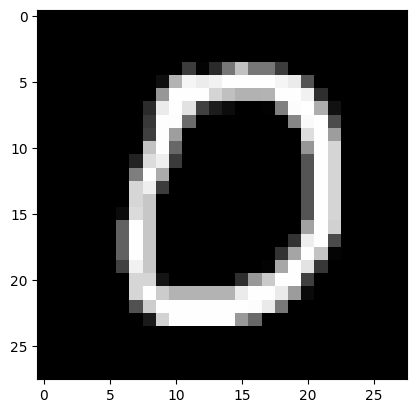

In [32]:
# En la variable Predicción, guardar la imagen que está en x_test en la posición 10.
prediccion = x_test[10]
# Muestrame la imagen que está en la variable prediccion
plt.imshow(prediccion, cmap='gray')


In [37]:
# Prediga la etiqueta de la imagen que está en la variable prediccion, mostrando el vector de resultados, no aplique soft-max
prediccion_vector = Mi_Modelo.predict(prediccion.reshape(1, 28, 28))
print(f"Predicción vector (sin softmax): {prediccion_vector}")

# Predicción de la etiqueta
prediccion_label = np.argmax(prediccion_vector)
print(f"Predicción de la etiqueta: {prediccion_label}")
# El mayor valor en la columna del vector de predicción corresponde a la etiqueta predicha por el modelo.
# Convertir la predicción vectorial a probabilidades con porcentaje, con dos decimales y %

prediccion_probabilidades = tf.nn.softmax(prediccion_vector)
# Mostrar probabilidades con dos decimales y porcentaje
prediccion_probabilidades_porcentaje = prediccion_probabilidades * 100
print(f"Predicción vector convertido a probabilidades con porcentaje: {prediccion_probabilidades_porcentaje.round(2)}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicción vector (sin softmax): [[  42.432278  -148.13176     -1.3581216  -36.318974  -125.21861
   -36.083546     1.9339931  -41.276413   -89.3566      -1.2556463]]
Predicción de la etiqueta: 0


AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'round'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


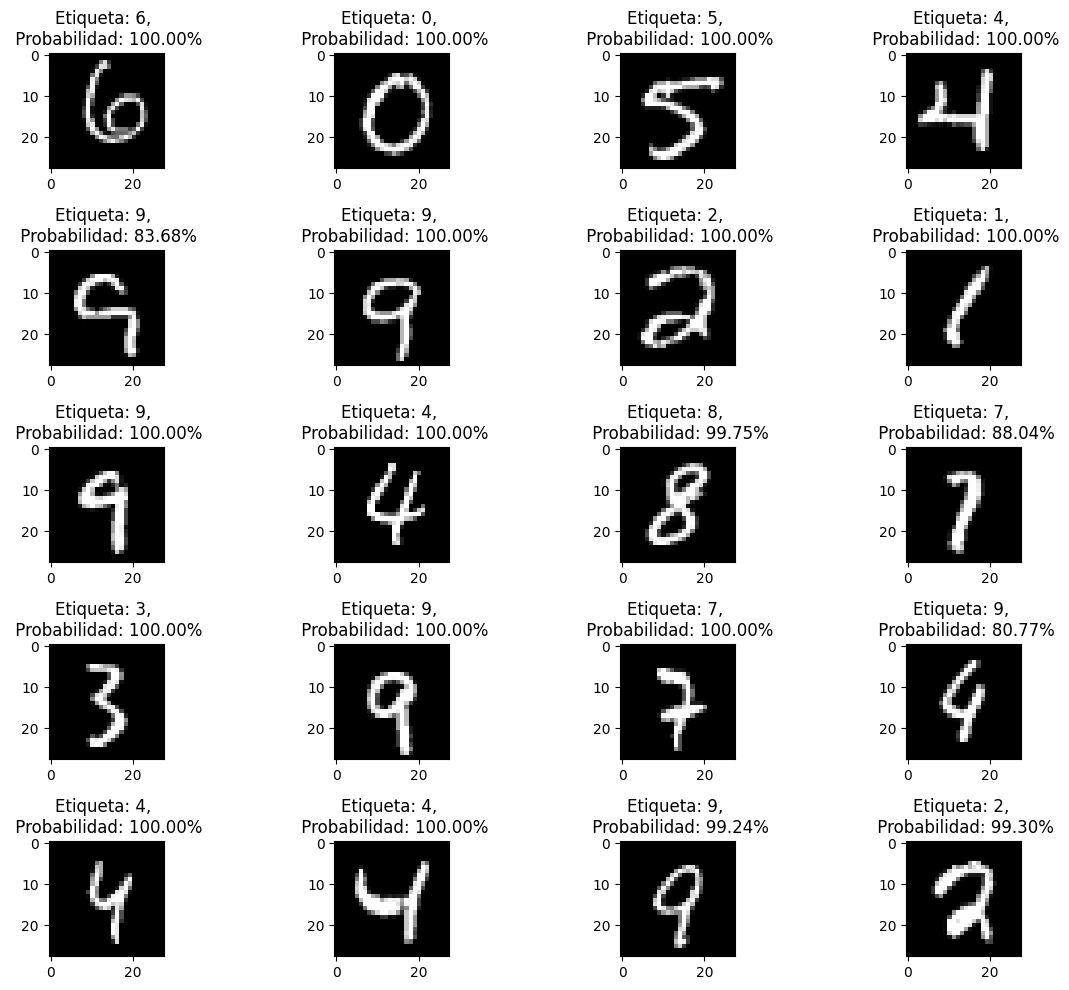

In [40]:
# Imprima las imagenes de la posición 100 a la 120 de x_test
# Haga la predicción, coloque la etiqueta en la parte superior, y en la parte inferior, la probabilidad de esa etiqueta
# Organice los numeros en 4 columnas y 5 filas, ajustando los tamaños
# Ajusta los tamaños de las etiquetas para que se vean bien, y el título de cada imagen, con la etiqueta y la probabilidad
plt.figure(figsize=(12, 10))
for i in range(20):
    plt.subplot(5, 4, i+1)
    plt.imshow(x_test[i+100], cmap='gray')
    prediccion = Mi_Modelo.predict(x_test[i+100].reshape(1, 28, 28))
    prediccion_softmax = tf.nn.softmax(prediccion)
    etiqueta = np.argmax(prediccion_softmax)
    probabilidad = np.max(prediccion_softmax) * 100
    plt.title(f"Etiqueta: {etiqueta}, \n Probabilidad: {probabilidad:.2f}%")
plt.tight_layout()
plt.show()


In [44]:
# Montar Google Drive de la carpeta "numeros" que está dentro de la carpeta "Ciencia de Datos"
from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta de la carpeta
ruta_carpeta = '/content/drive/MyDrive/Ciencia de Datos/numeros'

# Verificar si la carpeta existe
if os.path.exists(ruta_carpeta):
    print(f"Carpeta montada con éxito en: {ruta_carpeta}")
else:
    print("La ruta especificada no existe. Verifique el nombre de las carpetas.")

MessageError: [dfs_ephemeral] Credentials propagation unsuccessful

In [ ]:
import cv2

# Definir los nombres de los archivos
archivos_numeros = ['1.jpg', '6.jpg', '9.jpg', '4.jpg', '3.jpg']
imagenes_reales = []

for nombre in archivos_numeros:
    ruta_completa = os.path.join(ruta_carpeta, nombre)
    # Leer la imagen en escala de grises
    img = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        # Redimensionar a 28x28
        img_resized = cv2.resize(img, (28, 28))
        # Invertir colores si es fondo blanco y letras negras (MNIST es fondo negro, letras blancas)
        img_inverted = cv2.bitwise_not(img_resized)
        # Normalizar
        img_normalized = img_inverted / 255.0
        imagenes_reales.append(img_normalized)
    else:
        print(f"No se pudo cargar la imagen: {nombre}")

# Convertir a array de numpy
imagenes_reales = np.array(imagenes_reales)

# Importe los archivos de google drive de la carpeta "numeros" (1,6,9,4,3).jpg # Guardelos en una matriz 28x28 # Si es necesario, haga reshape a 28x28. Mantenga este comentario